In [1]:
import pandas as pd

file_path = "../data/evaluate.xlsx"
df = pd.read_excel(file_path)

In [2]:
df

,Name,MAE,RMSE,MASE,Coverage 90%,Model,Level
0,Global,0.311,0.5784,0.5784,0.8,Prophet,Global
1,South Asia,0.1476,0.2426,0.2380,1.0,Prophet,Region
2,Europe & Central Asia,0.7477,1.0884,0.3180,0.6,Prophet,Region
3,Middle East & North Africa,3.7768,8.5912,1.7440,0.7,Prophet,Region
4,East Asia & Pacific,0.3277,0.3494,0.1840,1.0,Prophet,Region
5,Sub-Saharan Africa,0.3452,0.4095,0.5590,0.9,Prophet,Region
6,Latin America & Carib,1.0791,1.5915,0.3040,1.0,Prophet,Region
7,North America,0.0543,0.0765,0.4830,0.7,Prophet,Region
8,Viet Nam,0.1147,0.1616,0.7520,0.8,Prophet,Country
9,Japan,1.6092,4.7236,1.1620,0.5,Prophet,Country


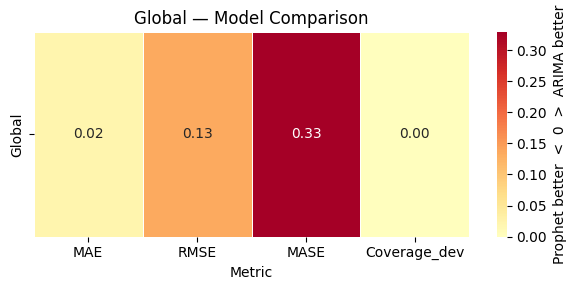

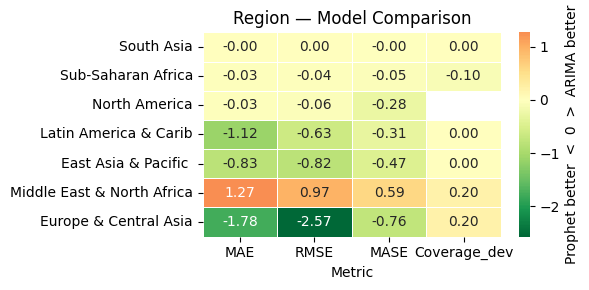

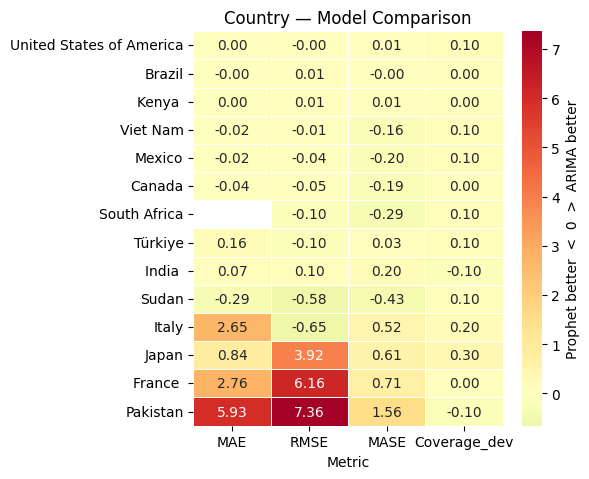

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ===== Chuẩn hoá numeric =====
num_cols = ["MAE", "RMSE", "MASE", "Coverage 90%"]
for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df["Coverage_dev"] = (df["Coverage 90%"] - 0.9).abs()

metrics = ["MAE", "RMSE", "MASE", "Coverage_dev"]

# ===== Tạo bảng diff =====
diff_tables = {}

for m in metrics:
    pivot = df.pivot(index="Name", columns="Model", values=m)
    diff = pivot["Prophet"] - pivot["ARIMA"]
    diff_tables[m] = diff

# ===== Hàm vẽ =====
def plot_level(level_name):
    names = df[df["Level"] == level_name]["Name"].unique()
    data = pd.DataFrame({m: diff_tables[m].loc[names] for m in metrics})

    # sort theo RMSE magnitude
    data = data.reindex(data["RMSE"].abs().sort_values().index)

    plt.figure(figsize=(6, max(3, len(data)*0.35)))
    sns.heatmap(
        data,
        annot=True,
        fmt=".2f",
        center=0,
        cmap="RdYlGn_r",
        linewidths=0.5,
        cbar_kws={"label": "Prophet better  <  0  >  ARIMA better"}
    )
    plt.title(f"{level_name} — Model Comparison")
    plt.xlabel("Metric")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()

# ===== Vẽ =====
plot_level("Global")
plot_level("Region")
plot_level("Country")

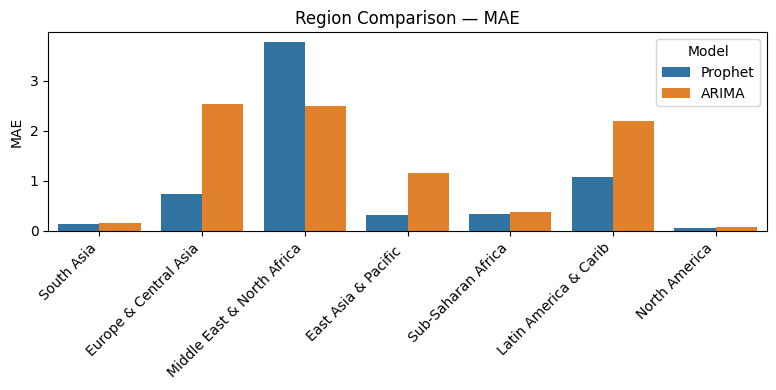

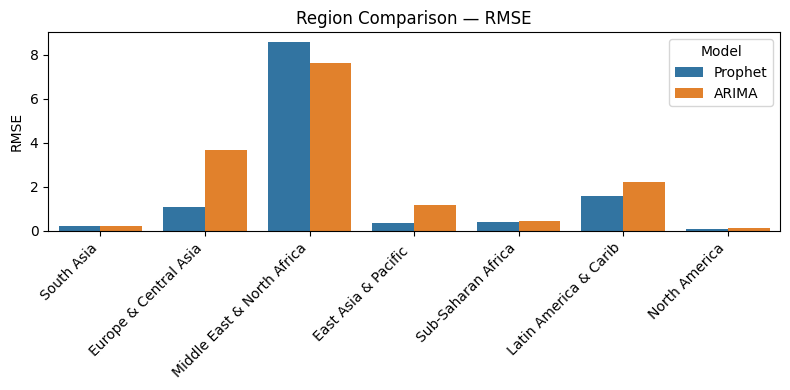

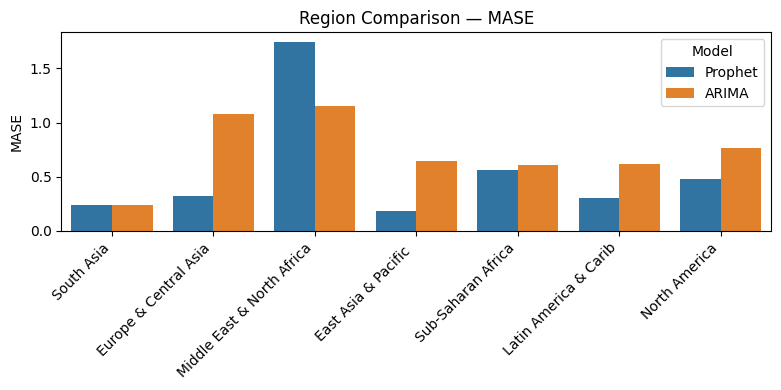

In [6]:
def plot_region_bar(metric):
    subset = df[df["Level"] == "Region"]

    plt.figure(figsize=(8,4))
    sns.barplot(
        data=subset,
        x="Name",
        y=metric,
        hue="Model"
    )
    plt.xticks(rotation=45, ha="right")
    plt.title(f"Region Comparison — {metric}")
    plt.xlabel("")
    plt.tight_layout()
    plt.show()

plot_region_bar("MAE")
plot_region_bar("RMSE")
plot_region_bar("MASE")

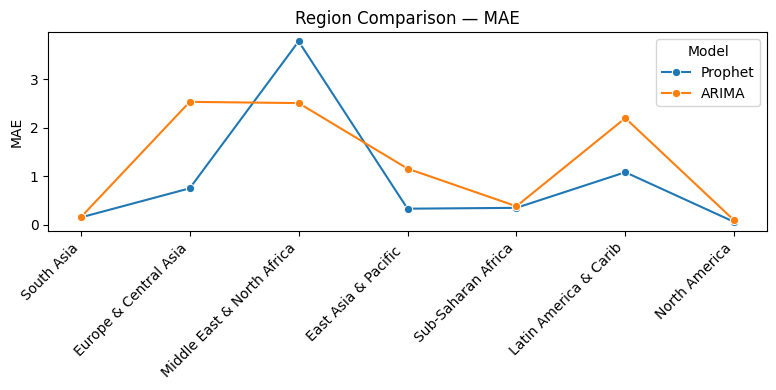

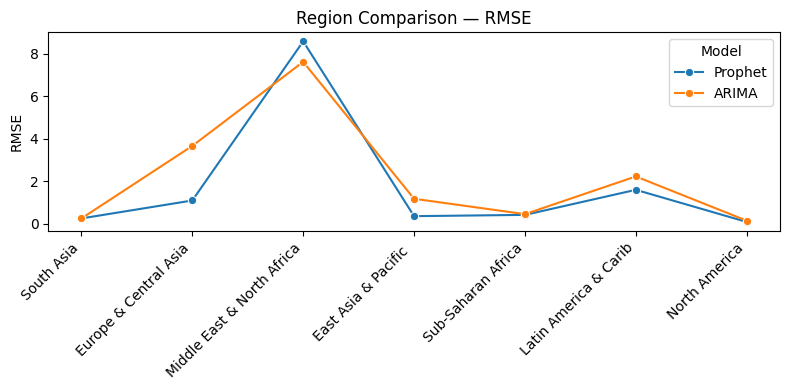

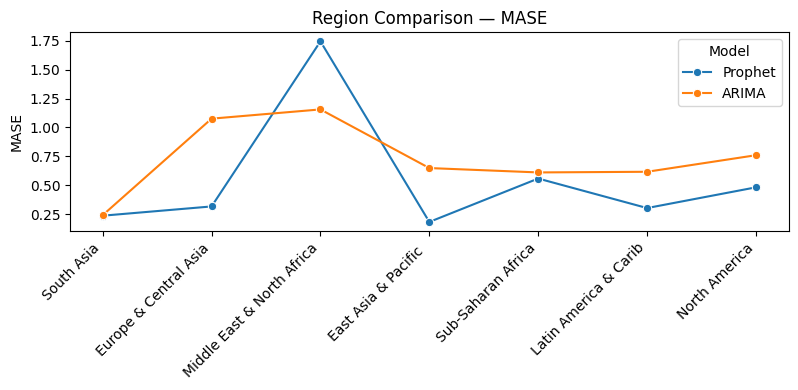

In [9]:
def plot_region_line(metric):
    subset = df[df["Level"] == "Region"]

    plt.figure(figsize=(8,4))
    sns.lineplot(
        data=subset,
        x="Name",
        y=metric,
        hue="Model",
        marker="o"
    )

    plt.xticks(rotation=45, ha="right")
    plt.title(f"Region Comparison — {metric}")
    plt.xlabel("")
    plt.tight_layout()
    plt.show()

plot_region_line("MAE")
plot_region_line("RMSE")
plot_region_line("MASE")

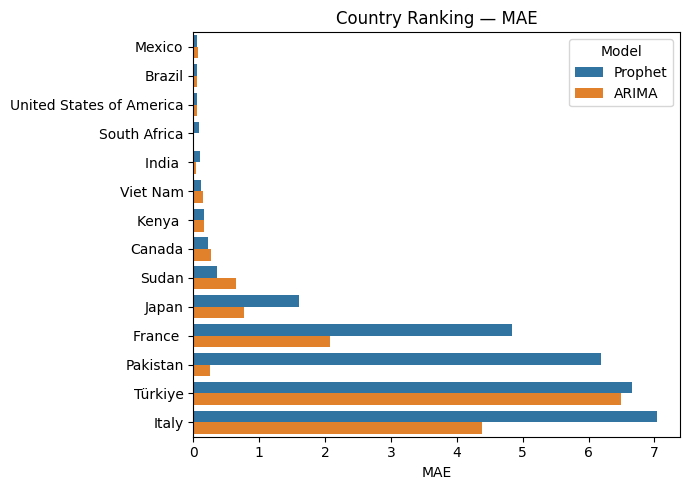

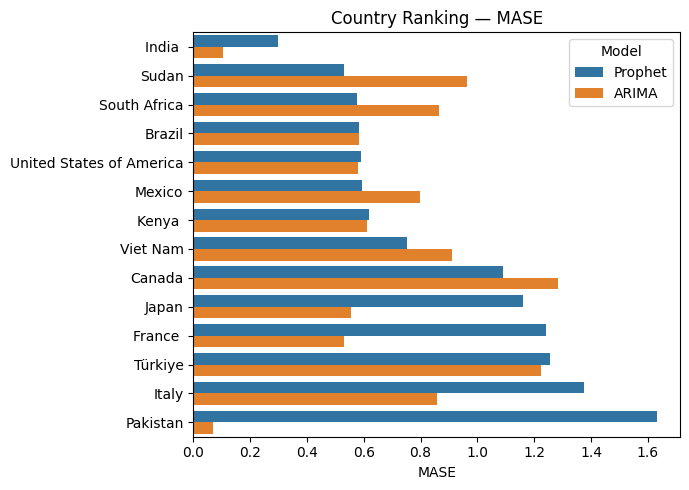

In [7]:
def plot_country_ranking(metric="MASE"):
    subset = df[df["Level"] == "Country"]

    order = (
        subset[subset["Model"] == "Prophet"]
        .sort_values(metric)["Name"]
    )

    plt.figure(figsize=(7,5))
    sns.barplot(
        data=subset,
        y="Name",
        x=metric,
        hue="Model",
        order=order
    )
    plt.title(f"Country Ranking — {metric}")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()

plot_country_ranking("MAE")
plot_country_ranking("MASE")

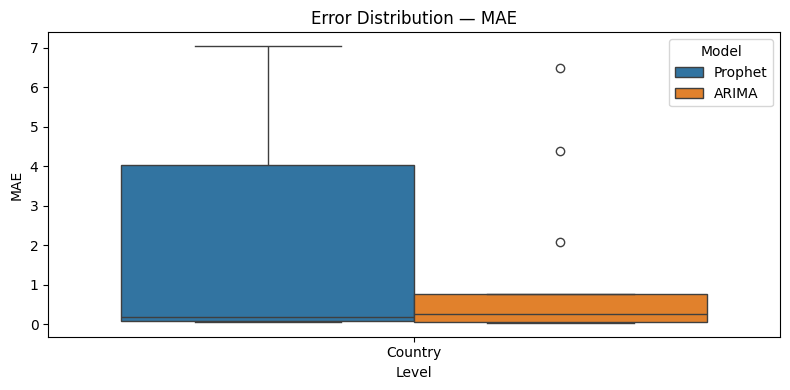

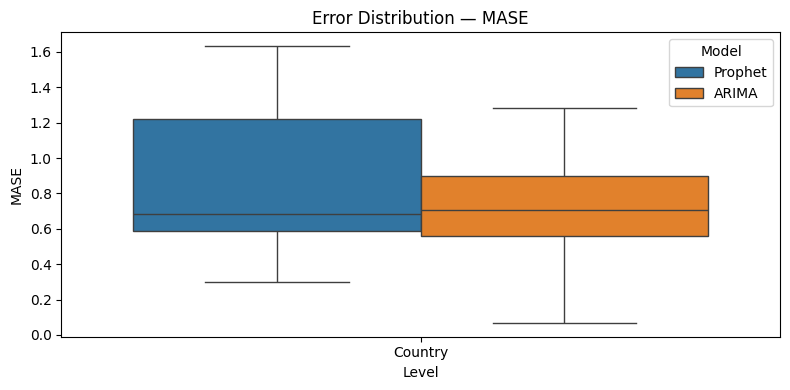

In [8]:
def plot_error_distribution(metric="MASE"):
    subset = df[df["Level"] == "Country"]

    plt.figure(figsize=(8,4))
    sns.boxplot(
        data=subset,
        x="Level",
        y=metric,
        hue="Model"
    )
    plt.title(f"Error Distribution — {metric}")
    plt.tight_layout()
    plt.show()

plot_error_distribution("MAE")
plot_error_distribution("MASE")